# NIFTY 50 EDA (2014-01-01 to 2016-12-31)
This notebook downloads daily NIFTY 50 prices, computes returns, and performs exploratory data analysis.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
%matplotlib inline

In [2]:
# Parameters
TICKER = '^NSEI'  # Yahoo ticker for NIFTY 50
START = '2014-01-01'
END = '2016-12-31'
OUT_DIR = os.path.join('..', 'data')
os.makedirs(OUT_DIR, exist_ok=True)
print('Output dir:', OUT_DIR)

Output dir: ..\data


In [3]:
# Download price data and save to CSV
df = yf.download(TICKER, start=START, end=END, progress=False)
if df.empty:
    raise RuntimeError('Data download returned empty DataFrame. Confirm ticker and network access.')
csv_path = os.path.join(OUT_DIR, 'nifty_2014_2016.csv')
df.to_csv(csv_path)
print('Saved:', csv_path)
df.head()

C:\Users\tejas\AppData\Local\Temp\ipykernel_16868\2805168193.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START, end=END, progress=False)


Saved: ..\data\nifty_2014_2016.csv


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2014-01-02,6221.149902,6358.299805,6211.299805,6301.250000,158100
2014-01-03,6211.149902,6221.700195,6171.250000,6194.549805,139000
2014-01-06,6191.450195,6224.700195,6170.250000,6220.850098,118300
2014-01-07,6162.250000,6221.500000,6144.750000,6203.899902,138600
2014-01-08,6174.600098,6192.100098,6160.350098,6178.049805,146900


In [4]:
df.isnull().sum()

Price   Ticker
Close   ^NSEI     0
High    ^NSEI     0
Low     ^NSEI     0
Open    ^NSEI     0
Volume  ^NSEI     0
dtype: int64

In [5]:
# Basic inspection
print('Shape:', df.shape)
display(df.describe().round(3))
display(df.info())

Shape: (728, 5)


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
count,728.000,728.000,728.000,728.000,728.000
mean,7917.152,7961.857,7872.440,7923.540,172135.165
std,692.506,695.068,691.867,696.620,51880.215
min,6000.900,6017.800,5933.300,5947.600,75500.000
25%,7624.100,7678.725,7581.950,7636.050,137250.000
50%,8059.000,8106.775,8005.125,8055.250,161600.000
75%,8432.350,8476.963,8380.600,8438.413,191600.000
max,8996.250,9119.200,8925.550,9109.150,473400.000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 728 entries, 2014-01-02 to 2016-12-30
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^NSEI)   728 non-null    float64
 1   (High, ^NSEI)    728 non-null    float64
 2   (Low, ^NSEI)     728 non-null    float64
 3   (Open, ^NSEI)    728 non-null    float64
 4   (Volume, ^NSEI)  728 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 34.1 KB


None

In [6]:
# Compute returns (simple and log) based on Close price
df = df.assign(Close=df['Close'])
df['return'] = df['Close'].pct_change()
df['log_return'] = np.log(df['Close']).diff()
df['log_price'] = np.log(df['Close'])
returns = df['return'].dropna()
log_returns = df['log_return'].dropna()
print('Computed returns — length:', len(returns))
returns.head()

Computed returns — length: 727


Date
2014-01-03   -0.001607
2014-01-06   -0.003172
2014-01-07   -0.004716
2014-01-08    0.002004
2014-01-09   -0.001012
Name: return, dtype: float64

### Exploratory Plots

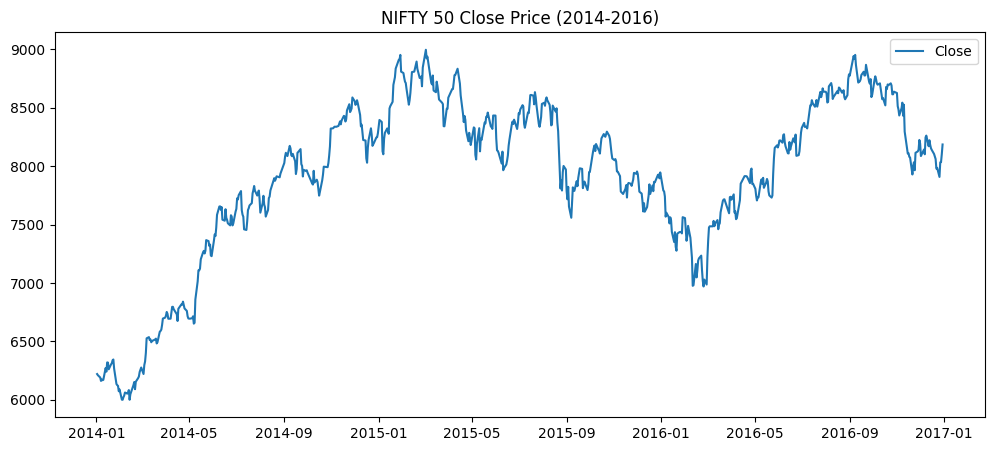

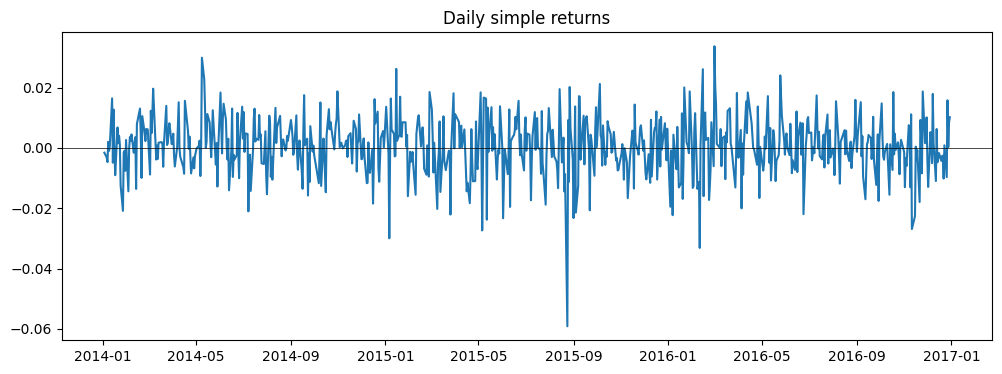

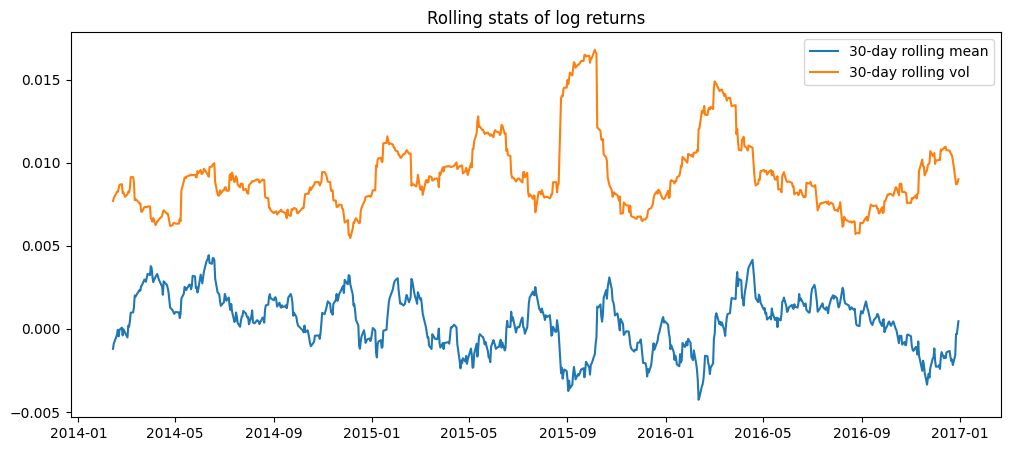

In [7]:
# Plots: Price, returns, rolling stats
plt.figure(figsize=(12,5))
plt.plot(df['Close'], label='Close')
plt.title('NIFTY 50 Close Price (2014-2016)')
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(returns, color='tab:blue')
plt.title('Daily simple returns')
plt.axhline(0, color='k', lw=0.5)
plt.show()

# Rolling mean and volatility (30-day)
rolling_mean = log_returns.rolling(window=30).mean()
rolling_vol = log_returns.rolling(window=30).std()
plt.figure(figsize=(12,5))
plt.plot(rolling_mean, label='30-day rolling mean')
plt.plot(rolling_vol, label='30-day rolling vol')
plt.legend()
plt.title('Rolling stats of log returns')
plt.show()

<Axes: xlabel='log_return', ylabel='Count'>

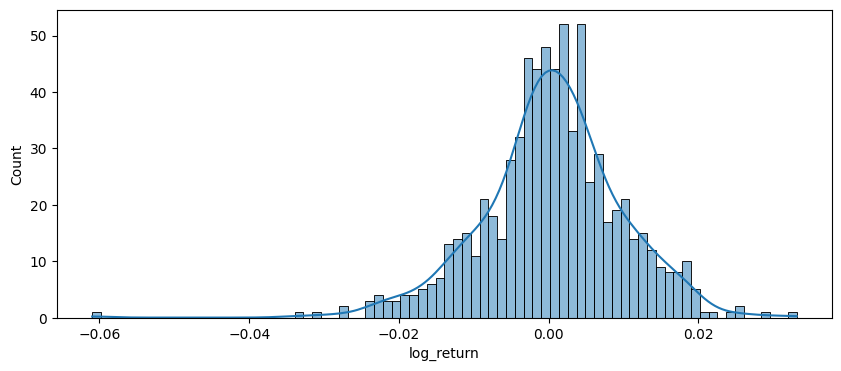

In [8]:
# Distribution checks
plt.figure(figsize=(10,4))
sns.histplot(log_returns, bins=80, kde=True)

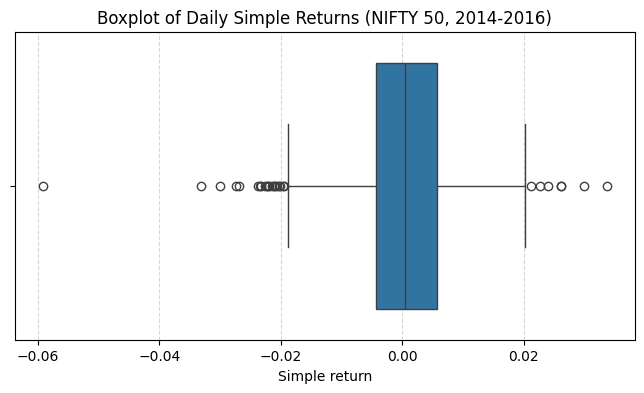

In [9]:
plt.figure(figsize=(8,4))
sns.boxplot(x=returns, color='tab:blue')
plt.title('Boxplot of Daily Simple Returns (NIFTY 50, 2014-2016)')
plt.xlabel('Simple return')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

### Summary Staistics

In [10]:
# Robustly get a 1D close price series (handle MultiIndex or single-column DF)
if 'Close' in df.columns:
    close_series = df['Close']
else:
    if isinstance(df.columns, pd.MultiIndex):
        if ('Close', TICKER) in df.columns:
            close_series = df[('Close', TICKER)]
        else:
            # try level 0 = 'Close'
            if 'Close' in df.columns.get_level_values(0):
                close_tmp = df.xs('Close', axis=1, level=0)
                close_series = close_tmp.iloc[:, 0] if isinstance(close_tmp, pd.DataFrame) else close_tmp
            else:
                # fallback: first numeric column
                close_series = df.select_dtypes(include=[np.number]).iloc[:, 0]
    else:
        close_series = df.select_dtypes(include=[np.number]).iloc[:, 0]

# Ensure we have a pandas Series
if isinstance(close_series, pd.DataFrame) and close_series.shape[1] == 1:
    close_series = close_series.iloc[:, 0]

# Basic descriptive stats
print("Close price summary:")
display(close_series.describe().round(4))

print("\nSimple returns summary:")
display(returns.describe().round(6))

print("\nLog returns summary:")
display(log_returns.describe().round(6))

# Additional moments and annualized metrics (assume ~252 trading days)
TRADING_DAYS = 252
extras = {
    'simple_returns': {
        'skew': float(returns.skew()),
        'kurtosis': float(returns.kurt()),
        'annualized_mean': float(returns.mean() * TRADING_DAYS),
        'annualized_vol': float(returns.std() * np.sqrt(TRADING_DAYS))
    },
    'log_returns': {
        'skew': float(log_returns.skew()),
        'kurtosis': float(log_returns.kurt()),
        'annualized_mean': float(log_returns.mean() * TRADING_DAYS),
        'annualized_vol': float(log_returns.std() * np.sqrt(TRADING_DAYS))
    },
    'price_derived': {
        'price_skew': float(close_series.skew()),
        'price_kurtosis': float(close_series.kurt()),
        'annualized_return_from_prices': float(returns.mean() * TRADING_DAYS),
        'annualized_vol_from_prices': float(returns.std() * np.sqrt(TRADING_DAYS))
    }
}

print("\nAdditional stats (skew, kurtosis, annualized mean & vol):")
display(pd.DataFrame(extras).round(6))

Close price summary:


count     728.0000
mean     7917.1521
std       692.5063
min      6000.8999
25%      7624.1000
50%      8059.0000
75%      8432.3501
max      8996.2500
Name: ^NSEI, dtype: float64


Simple returns summary:


count    727.000000
mean       0.000421
std        0.009363
min       -0.059151
25%       -0.004300
50%        0.000426
75%        0.005723
max        0.033669
Name: return, dtype: float64


Log returns summary:


count    727.000000
mean       0.000378
std        0.009382
min       -0.060973
25%       -0.004309
50%        0.000426
75%        0.005707
max        0.033115
Name: log_return, dtype: float64


Additional stats (skew, kurtosis, annualized mean & vol):


,simple_returns,log_returns,price_derived
skew,-0.460196,-0.523126,NaN
kurtosis,2.593278,2.848084,NaN
annualized_mean,0.106210,0.095131,NaN
annualized_vol,0.148639,0.148927,NaN
price_skew,NaN,NaN,-1.030424
price_kurtosis,NaN,NaN,0.549703
annualized_return_from_prices,NaN,NaN,0.106210
annualized_vol_from_prices,NaN,NaN,0.148639


### ADF Test on Returns

In [11]:
def stationarity_tests(series, name):
    """
    Run ADF and KPSS on a pandas Series
    """
    s = series.dropna()
    print(f"\n=== Stationarity tests for: {name} (n={len(s)}) ===")

    # ADF (null = non-stationary)
    adf_res = adfuller(s, autolag='AIC')
    adf_stat, adf_p, adf_lag, adf_nobs, adf_crit = adf_res[0], adf_res[1], adf_res[2], adf_res[3], adf_res[4]
    print("\nAugmented Dickey-Fuller test (null: unit root / non-stationary)")
    print(f" ADF statistic : {adf_stat:.6f}")
    print(f" p-value       : {adf_p:.6f}")
    print(f" usedlag       : {adf_lag}, nobs: {adf_nobs}")
    print(" critical vals : " + ", ".join([f"{k}: {v:.4f}" for k, v in adf_crit.items()]))
    if adf_p < 0.05:
        print(" => ADF: reject null (series appears stationary at 5% level)")
    else:
        print(" => ADF: fail to reject null (series appears non-stationary)")

# Run tests on the log returns and on the log-price series

stationarity_tests(log_returns, "Log returns")
stationarity_tests(df['log_price'], "Log(price)")


=== Stationarity tests for: Log returns (n=727) ===

Augmented Dickey-Fuller test (null: unit root / non-stationary)
 ADF statistic : -14.660295
 p-value       : 0.000000
 usedlag       : 2, nobs: 724
 critical vals : 1%: -3.4394, 5%: -2.8655, 10%: -2.5689
 => ADF: reject null (series appears stationary at 5% level)

=== Stationarity tests for: Log(price) (n=728) ===

Augmented Dickey-Fuller test (null: unit root / non-stationary)
 ADF statistic : -2.711077
 p-value       : 0.072141
 usedlag       : 3, nobs: 724
 critical vals : 1%: -3.4394, 5%: -2.8655, 10%: -2.5689
 => ADF: fail to reject null (series appears non-stationary)


### ACP And PACF

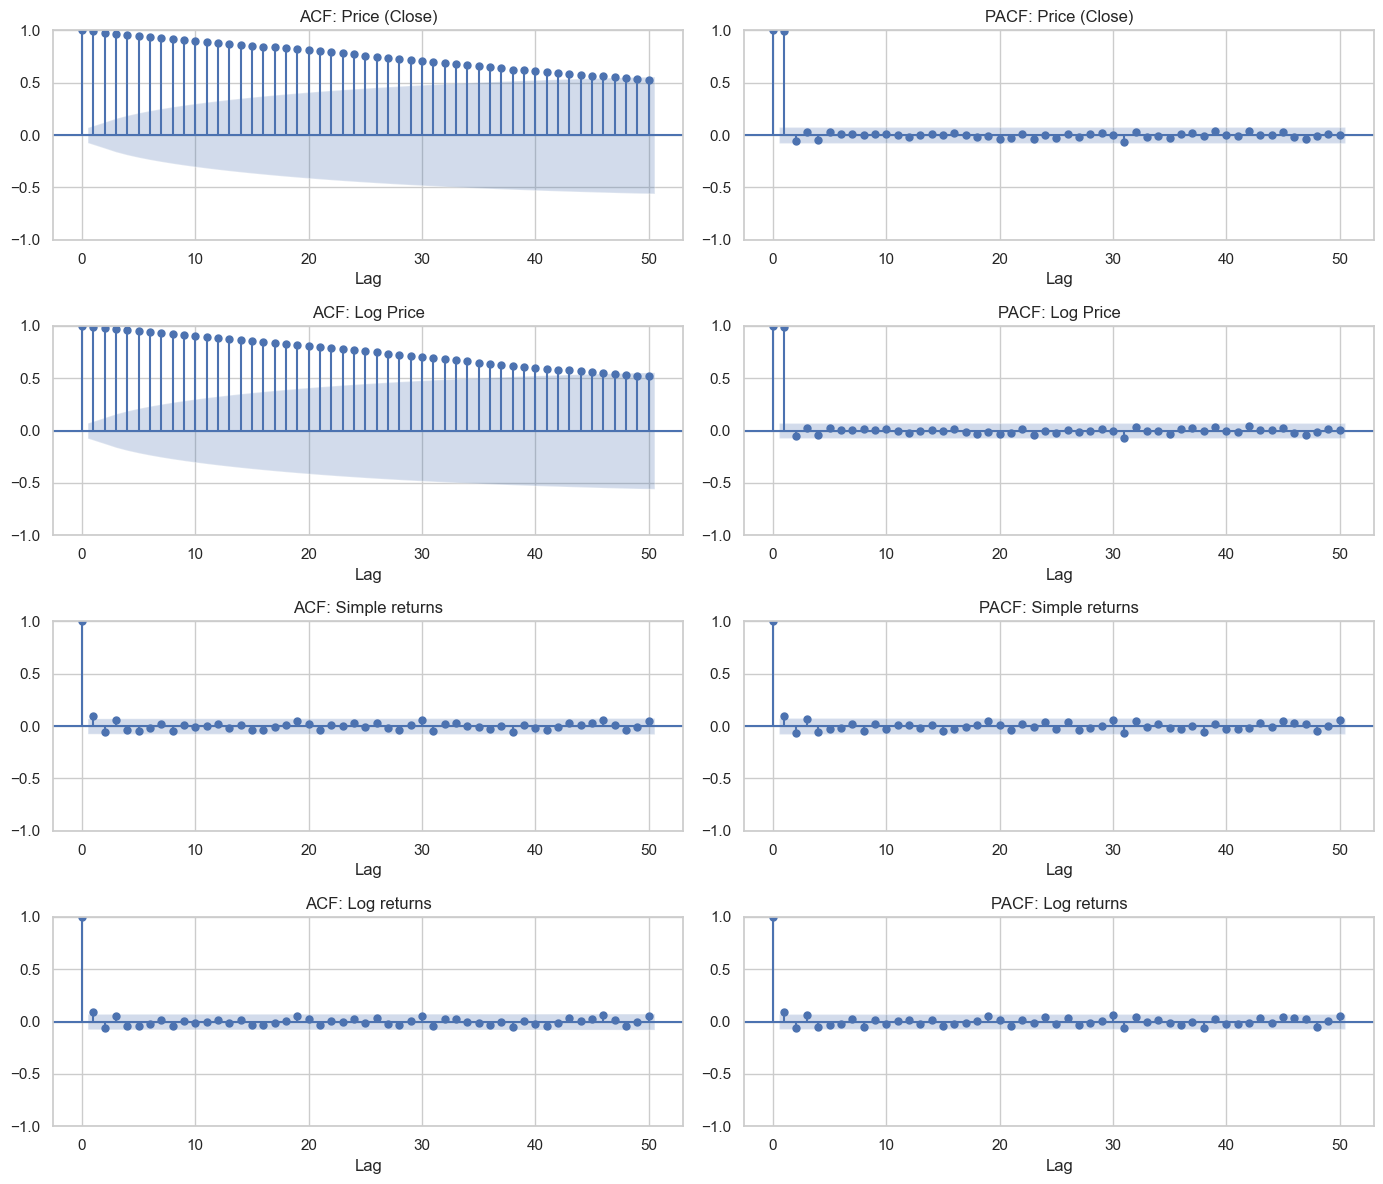

In [12]:
# ACF & PACF for: price levels, log price, simple returns, log returns
# Uses existing variables: close_series, log_price, returns, log_returns, lags
sns.set(style='whitegrid', context='notebook')

series_map = [
    ("Price (Close)", close_series),
    ("Log Price", df['log_price']),
    ("Simple returns", returns),
    ("Log returns", log_returns)
]

lags = 50

fig, axes = plt.subplots(len(series_map), 2, figsize=(14, 12))
for i, (label, s) in enumerate(series_map):
    s_clean = s.dropna()
    # ACF (left)
    plot_acf(s_clean, lags=lags, ax=axes[i, 0], zero=True)
    axes[i, 0].set_title(f'ACF: {label}')
    axes[i, 0].set_xlabel('Lag')
    axes[i, 0].tick_params(axis='x', rotation=0)

    # PACF (right)
    plot_pacf(s_clean, lags=lags, ax=axes[i, 1], method='ywm')
    axes[i, 1].set_title(f'PACF: {label}')
    axes[i, 1].set_xlabel('Lag')
    axes[i, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Distribution Check

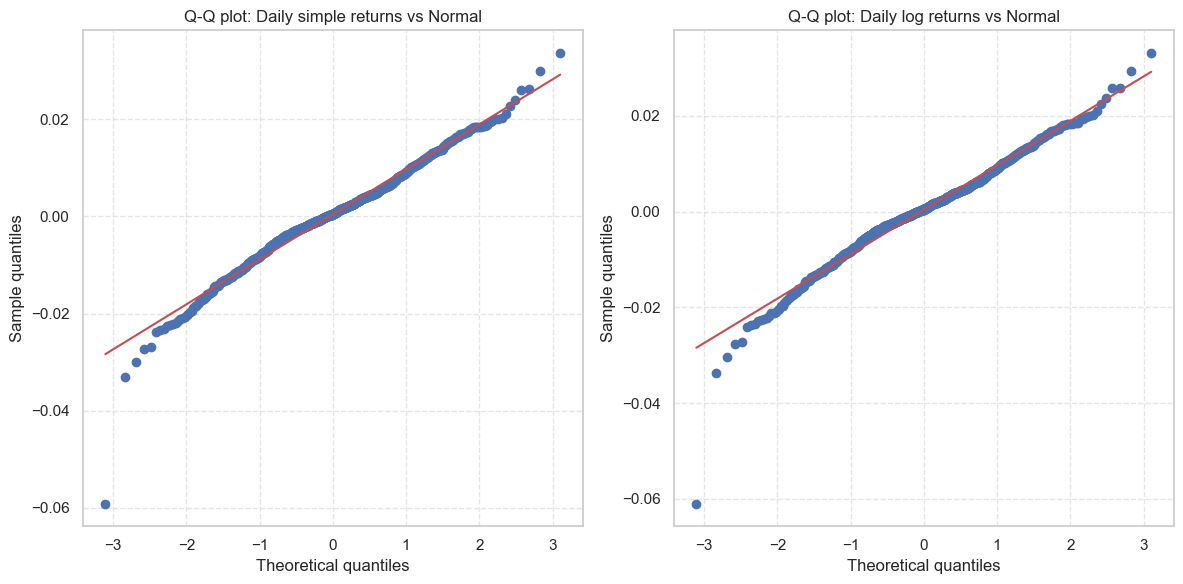

In [14]:
# Q-Q plots: simple returns and log returns with seaborn styling
sns.set(style='whitegrid', context='notebook')

r = returns.dropna()
lr = log_returns.dropna()

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Simple returns QQ
stats.probplot(r, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q plot: Daily simple returns vs Normal")
axes[0].set_xlabel("Theoretical quantiles")
axes[0].set_ylabel("Sample quantiles")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Log returns QQ
stats.probplot(lr, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot: Daily log returns vs Normal")
axes[1].set_xlabel("Theoretical quantiles")
axes[1].set_ylabel("Sample quantiles")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [15]:
# Summary statistics for shape: skewness, kurtosis, and simple interpretation
def shape_summary(series, name):
    s = series.dropna()
    n = len(s)
    if n == 0:
        print(f"{name}: empty series")
        return

    skew = float(stats.skew(s))
    # Pearson kurtosis where normal == 3.0
    kurtosis_pearson = float(stats.kurtosis(s, fisher=False))
    # excess kurtosis where normal == 0.0
    kurtosis_excess = float(stats.kurtosis(s, fisher=True))

    # Approx standard errors (large-sample approximations)
    se_skew = np.sqrt(6.0 / n)
    se_kurt = np.sqrt(24.0 / n)

    # z-statistics and two-sided p-values
    z_skew = skew / se_skew
    p_skew = 2 * (1.0 - stats.norm.cdf(abs(z_skew)))

    z_kurt = kurtosis_excess / se_kurt
    p_kurt = 2 * (1.0 - stats.norm.cdf(abs(z_kurt)))

    # Interpretations per workflow
    if kurtosis_pearson > 5.0:
        kurt_interp = "Strong heavy tails (kurtosis > 5) → normal distribution inappropriate."
    elif kurtosis_pearson > 3.0:
        kurt_interp = "Heavier tails than normal (kurtosis > 3)."
    else:
        kurt_interp = "No heavy tails relative to normal (kurtosis ≤ 3)."

    if p_skew < 0.05:
        skew_interp = ("Skewness significantly ≠ 0 (p < 0.05) → asymmetric shocks matter; "
                       "consider EGARCH or skew‑t innovations.")
    else:
        skew_interp = "Skewness not significantly different from 0 (p ≥ 0.05)."

    # Print concise summary
    print(f"--- {name} (n={n}) ---")
    print(f"Skewness           : {skew:.6f}")
    print(f"  SE(skew)         : {se_skew:.6f}, z = {z_skew:.3f}, p = {p_skew:.4f}")
    print(f"Kurtosis (Pearson): {kurtosis_pearson:.6f}  (excess = {kurtosis_excess:.6f})")
    print(f"  SE(excess kurt)  : {se_kurt:.6f}, z = {z_kurt:.3f}, p = {p_kurt:.4f}")
    print("\nInterpretation:")
    print(" -", kurt_interp)
    print(" -", skew_interp)
    print()

# Run for simple and log returns (uses existing `returns` and `log_returns`)
shape_summary(returns, "Daily simple returns")
shape_summary(log_returns, "Daily log returns")

--- Daily simple returns (n=727) ---
Skewness           : -0.459246
  SE(skew)         : 0.090847, z = -5.055, p = 0.0000
Kurtosis (Pearson): 5.567235  (excess = 2.567235)
  SE(excess kurt)  : 0.181693, z = 14.130, p = 0.0000

Interpretation:
 - Strong heavy tails (kurtosis > 5) → normal distribution inappropriate.
 - Skewness significantly ≠ 0 (p < 0.05) → asymmetric shocks matter; consider EGARCH or skew‑t innovations.

--- Daily log returns (n=727) ---
Skewness           : -0.522046
  SE(skew)         : 0.090847, z = -5.746, p = 0.0000
Kurtosis (Pearson): 5.820292  (excess = 2.820292)
  SE(excess kurt)  : 0.181693, z = 15.522, p = 0.0000

Interpretation:
 - Strong heavy tails (kurtosis > 5) → normal distribution inappropriate.
 - Skewness significantly ≠ 0 (p < 0.05) → asymmetric shocks matter; consider EGARCH or skew‑t innovations.



### Volatility Diagnostics

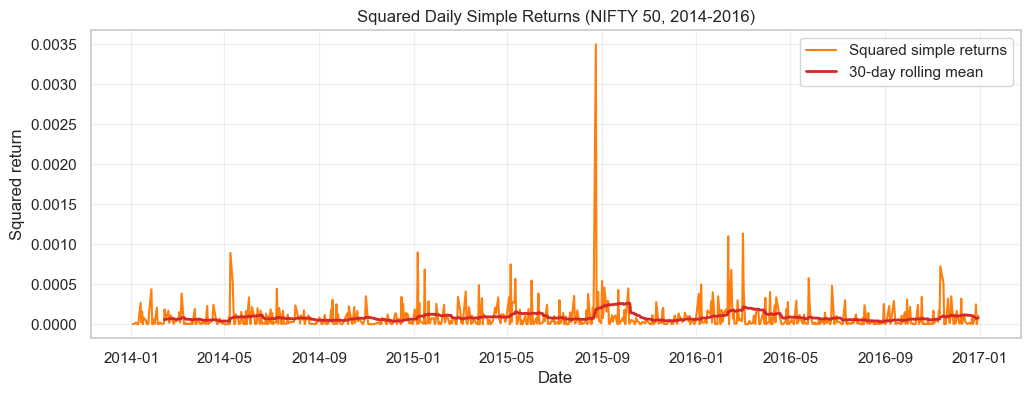

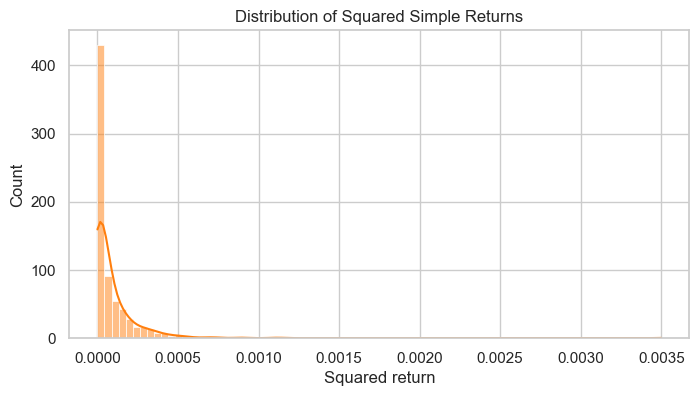

In [17]:
# Squared simple returns plot
sq_returns = (returns ** 2).dropna()

plt.figure(figsize=(12,4))
plt.plot(sq_returns, color='tab:orange', label='Squared simple returns')
plt.plot(sq_returns.rolling(30).mean(), color='tab:red', lw=2, label='30-day rolling mean')
plt.title('Squared Daily Simple Returns (NIFTY 50, 2014-2016)')
plt.xlabel('Date')
plt.ylabel('Squared return')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Optional: distribution of squared returns
plt.figure(figsize=(8,4))
sns.histplot(sq_returns, bins=80, kde=True, color='tab:orange')
plt.title('Distribution of Squared Simple Returns')
plt.xlabel('Squared return')
plt.show()

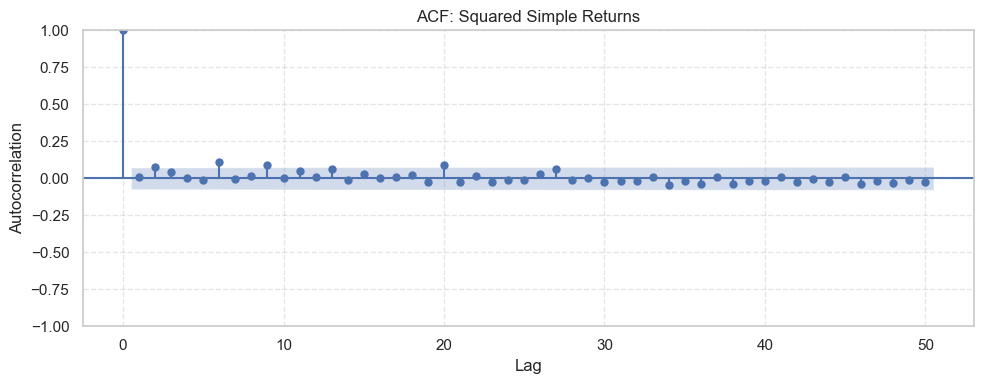

In [18]:
# ACF of squared returns
s_sq = sq_returns.dropna()
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(s_sq, lags=lags, ax=ax, zero=True)
ax.set_title('ACF: Squared Simple Returns')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [20]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Lags to test (don't overwrite existing `lags` variable)
lags_to_test = [5, 10, 20, 30, 40, 50]

def run_ljung_box(series, lags):
    """Run Ljung-Box and return a tidy DataFrame (uses return_df=True)."""
    s = series.dropna()
    return acorr_ljungbox(s, lags=lags, return_df=True)

print("Ljung-Box on raw returns:")
display(run_ljung_box(returns, lags_to_test).round(6))

print("\nLjung-Box on squared returns:")
display(run_ljung_box(sq_returns, lags_to_test).round(6))

# Interpret Ljung-Box tables produced above
res_r = run_ljung_box(returns, lags_to_test)
res_sq = run_ljung_box(sq_returns, lags_to_test)

def _pcol(df):
    for c in df.columns:
        lc = c.lower()
        if 'p' in lc and ('value' in lc or 'value' in lc.replace('-', '')):
            return c
    # fallback common name
    for cand in ('lb_pvalue', 'lb_p_value', 'pvalue', 'p_value', 'p-value'):
        if cand in df.columns:
            return cand
    return None

def interpret_lb(res, name, alpha=0.05):
    pcol = _pcol(res)
    if pcol is None:
        print(f"{name}: could not find p-value column in results.")
        display(res.round(6))
        return

    sig = res[res[pcol] < alpha]
    print(f"Interpretation for: {name}")
    if sig.empty:
        print(f" - No evidence to reject the null of no autocorrelation up to lag {res.index.max()} (all p ≥ {alpha}).")
    else:
        lags_sig = sig.index.tolist()
        print(f" - Evidence of autocorrelation at lag(s): {lags_sig} (p < {alpha}).")
        print(" - See p-values for those lags:")
        display(res.loc[lags_sig, [pcol]].round(6))
    print()

interpret_lb(res_r, "Raw/simple returns")
interpret_lb(res_sq, "Squared returns (tests for ARCH/volatility clustering)")

Ljung-Box on raw returns:


,lb_stat,lb_pvalue
5,13.453446,0.019481
10,15.467299,0.115931
20,20.539625,0.424660
30,26.593499,0.644526
40,32.695947,0.787152
50,41.597792,0.795259



Ljung-Box on squared returns:


,lb_stat,lb_pvalue
5,6.199142,0.287321
10,21.288017,0.019172
20,33.942724,0.026515
30,39.301919,0.119108
40,44.235769,0.297429
50,48.108343,0.549605


Interpretation for: Raw/simple returns
 - Evidence of autocorrelation at lag(s): [5] (p < 0.05).
 - See p-values for those lags:


,lb_pvalue
5,0.019481



Interpretation for: Squared returns (tests for ARCH/volatility clustering)
 - Evidence of autocorrelation at lag(s): [10, 20] (p < 0.05).
 - See p-values for those lags:


,lb_pvalue
10,0.019172
20,0.026515
